In [ ]:
# Dataset 1
# Installed capacity has a strong positive relationship with energy production.
# Financial incentives encourage renewable investment.
# Energy production increases with storage efficiency.
# Scaling improves model stability.
# Feature engineering improves prediction performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("/content/drive/MyDrive/energy_dataset_.csv")
print(df.info())
print(df.head())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Type_of_Renewable_Energy       15000 non-null  int64  
 1   Installed_Capacity_MW          15000 non-null  float64
 2   Energy_Production_MWh          15000 non-null  float64
 3   Energy_Consumption_MWh         15000 non-null  float64
 4   Energy_Storage_Capacity_MWh    15000 non-null  float64
 5   Storage_Efficiency_Percentage  15000 non-null  float64
 6   Grid_Integration_Level         15000 non-null  int64  
 7   Initial_Investment_USD         15000 non-null  float64
 8   Funding_Sources                15000 non-null  int64  
 9   Financial_Incentives_USD       15000 non-null  float64
 10  GHG_Emission_Reduction_tCO2e   15000 non-null  float64
 11  Air_Pollution_Reduction_Index  15000 non-null  float64
 12  Jobs_Created                   15000 non-null 

In [3]:
df = pd.get_dummies(df, drop_first=True)

df["Production_per_MW"] = (df["Energy_Production_MWh"] / df["Installed_Capacity_MW"])

X = df.drop("Energy_Production_MWh", axis=1)
y = df["Energy_Production_MWh"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print(r2_score(y_test,pred))
print(mean_absolute_error(y_test,pred))
print(np.sqrt(mean_squared_error(y_test,pred)))

0.009032060364163152
124520.38363277412
143454.90665644503


In [4]:
# Dataset 2
# Temperature and CO₂ concentration influence energy load.
# Renewable share reduces dependence on conventional energy.
# Logistic Regression classifies high vs. low energy demand effectively.
# Standardization improves convergence.
# Confusion Matrix helps identify misclassified samples.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("/content/drive/MyDrive/regional_climate_energy_dataset.csv")
print("\nFirst 5 Rows")
print(df.head())
print("\nDataset Shape")
print(df.shape)
print("\nInformation")
print(df.info())
print("\nDescription")
print(df.describe())
print("\nMissing Values")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


First 5 Rows
   Temperature_C  Humidity_percent  WindSpeed_m_s     CO2_ppm  \
0      27.483571         40.048955       3.286032  400.899496   
1      24.308678         36.274070       0.550820  413.169255   
2      28.238443         68.185815       1.620386  428.001184   
3      32.615149         72.388544       5.082910  402.621463   
4      23.829233         31.895169      12.038785  381.851709   

   RadiativeForcing_W_m2  EnergyConsumption_MW  RenewableShare_percent  \
0               1.513311            472.245574               83.557171   
1               2.503567            629.127384                4.366093   
2               2.168072            542.178007               23.663313   
3               1.886262            631.019191               88.974899   
4               1.588032            478.403948                0.916555   

   TemperatureAnomaly_C  EnergyLoad_MW  
0              1.392456     464.619356  
1             -1.100476     623.984859  
2              1.155829    

High_Load
0    500
1    500
Name: count, dtype: int64

Accuracy
0.925

Confusion Matrix
[[95  5]
 [10 90]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.95      0.93       100
           1       0.95      0.90      0.92       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.92       200
weighted avg       0.93      0.93      0.92       200



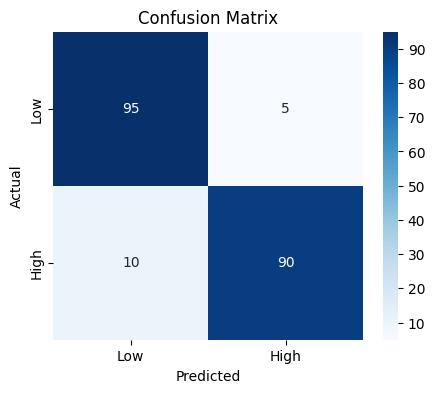

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

median_load = df["EnergyLoad_MW"].median()
df["High_Load"] = np.where(df["EnergyLoad_MW"] > median_load, 1, 0)
print(df["High_Load"].value_counts())
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

X = df.drop(["EnergyLoad_MW", "High_Load"], axis=1)
y = df["High_Load"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy")
print(accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Low","High"],
            yticklabels=["Low","High"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()